# SC2001 Lab 2 - Dijkstra's Algorithm

In [2]:

import heapq
import random
import numpy as np

import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
import time

warnings.filterwarnings("ignore")
seed = 1234
random.seed(seed)
np.random.seed(seed)

# (a) Dijkstra Algorithm (Adjacency matrix + Array)
Suppose the input graph G = (V, E) is stored in an adjacency matrix and we use an array for the priority queue. Implement the Dijkstra’s algorithm using this setting and analyze its time complexity with respect to |V| and |E| both theoretically and empirically.

In [3]:
def dijkstra_matrix_array(adjMatrix, sourceNode):
    d = [] # array of estimates for lengths of shortest paths from source node
    pi = [] # array of predecessors for each vertex
    S =  [] # set of vertices whose shortest path from source already determined
    priorityQueue = [] # Priority Queue Q

    infinity = float('inf')
    graphLength = len(adjMatrix)

    for i in range(graphLength):
        d.append(infinity)

        pi.append(-1) # set predecessor to NULL, pi[v] = null
        S.append(0) # set solution set S to empty at first, where all v not in S
        priorityQueue.append(i)

    d[sourceNode] = 0 # set estimated distance to itself (src to src) to be 0

    while len(priorityQueue) != 0: # if Q not empty
        # Implementation of u = ExtractCheapest(Q)
        cheapest = 0
        for i in range(len(priorityQueue)):
            if (d[priorityQueue[i]] < d[priorityQueue[cheapest]]):
                cheapest = i
        u = priorityQueue.pop(cheapest)
        S[u] = 1 # add u to S
        for i in range(graphLength): # for each vertex v adjacent to u
            vertex = i
            weight = adjMatrix[u][i]

            if (weight > 0):
                # if vertex v not in solution set & estimated distance distance
                # of vertex v bigger than src node + weighted edge[u, v]
                if ((S[vertex] != 1) and (d[vertex] > (d[u] + weight))):
                    d[vertex] = d[u] + weight # update the new shortest value
                    pi[vertex] = u # set predecessor of vertex v as u
    return d, pi

In [4]:
def graph_generator(n, e):
    matrix = [[0 for _ in range(n)] for _ in range(n)]
    max_edges = n * (n - 1) // 2

    # Fully connect if dense
    if e >= 0.9 * max_edges:
        for i in range(n):
            for j in range(i + 1, n):
                w = random.randint(1, 100)
                matrix[i][j] = w
                matrix[j][i] = w
        return matrix

    while e > 0:
        a = random.randint(0, n - 1)
        b = random.randint(0, n - 1)
        if a != b and matrix[a][b] == 0:
            w = random.randint(1, 100)
            matrix[a][b] = w
            matrix[b][a] = w
            e -= 1

    return matrix

In [5]:
# Complete Graph
n = 10
e = n*(n-1)
incom_adjMatrixTest = graph_generator(n, e)
for i in incom_adjMatrixTest:
    print(i)

[0, 100, 57, 15, 1, 12, 75, 5, 86, 89]
[100, 0, 11, 13, 99, 46, 31, 3, 4, 3]
[57, 11, 0, 45, 83, 80, 62, 79, 60, 20]
[15, 13, 45, 0, 12, 24, 92, 15, 2, 65]
[1, 99, 83, 12, 0, 63, 32, 9, 86, 70]
[12, 46, 80, 24, 63, 0, 60, 9, 77, 87]
[75, 31, 62, 92, 32, 60, 0, 12, 66, 75]
[5, 3, 79, 15, 9, 9, 12, 0, 6, 35]
[86, 4, 60, 2, 86, 77, 66, 6, 0, 72]
[89, 3, 20, 65, 70, 87, 75, 35, 72, 0]


## Theoretical Analysis
We expect the Dijkstra's Shortest Path Search algorithm to have a time complexity of *O(|V|²)*.

## Derivations

- Since we are working with directed and connected graph, we guarantee to visit all nodes.  This incurs a search cost of *O(|V|)*.
- On each iteration, we expand the vertex with smallest distance from start vertex. We find this vertex by traversing through the dist[] array and find the minimum. This incurs a search cost of *O(|V|)*.
- On each iteration, we check if the other vertices are connected to it.

This incurs a search cost of *O(|V| - 1)*.
Thus, DIjkstra's Shortest Path Search algorithm on adjacency matrix with array-based Priority Queue has a time complexity of *O(|V|)* x (*O(|V|)* + *O(|V| - 1)) = O(|V|²)*.

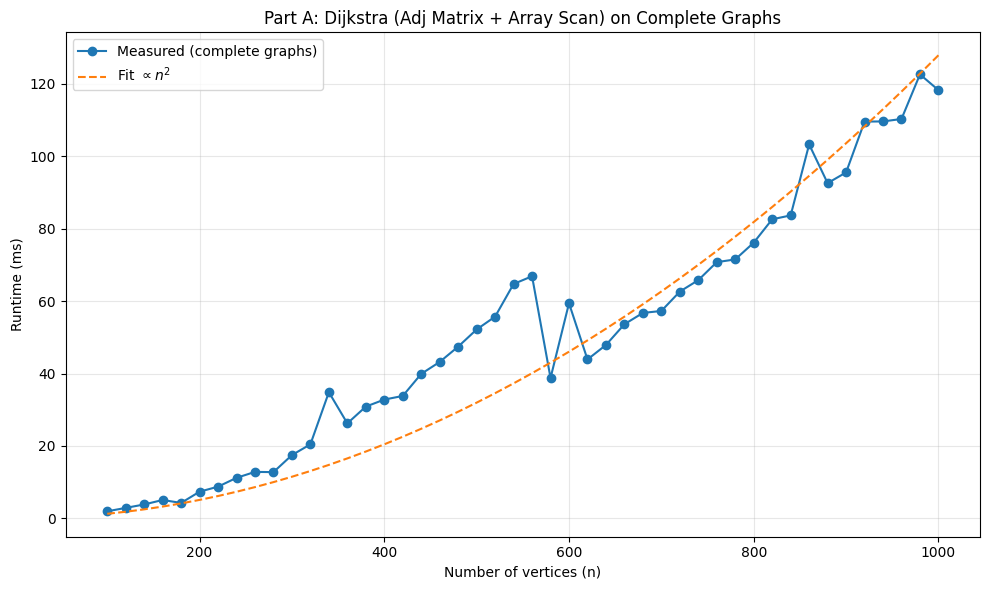

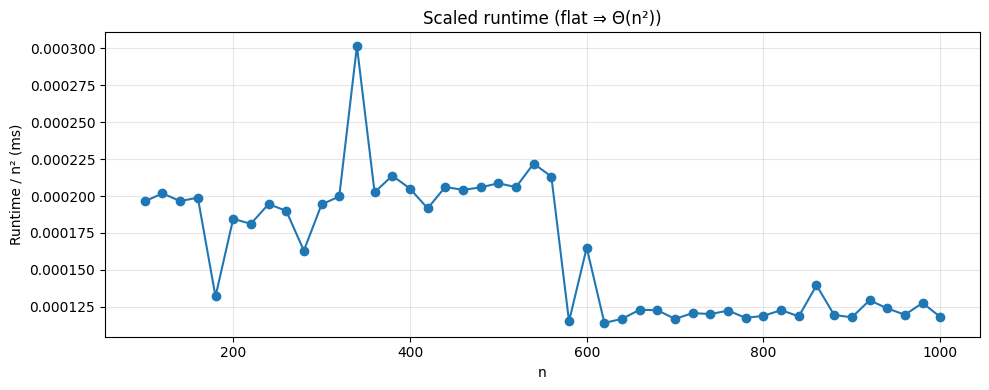

In [6]:
# ---------- Linear-n experiment (n = 100, 200, ..., 1000) ----------
import time
from statistics import mean
import numpy as np
import matplotlib.pyplot as plt


def time_dijkstra_only(adj, src=0):
    t0 = time.perf_counter()
    dijkstra_matrix_array(adj, src)
    t1 = time.perf_counter()
    return (t1 - t0) * 1000.0  # ms

def runtime_vs_n_complete_linear(
    n_start=100,
    n_end=1000,
    step=20,
    trials=1,
    src=0,
    title="Part A: Dijkstra (Adj Matrix + Array Scan) on Complete Graphs"
):
    ns, times = [], []

    for n in range(n_start, n_end + 1, step):
        e = n * (n - 1)  # complete directed, no self-loops
        # Pre-generate graphs so timing excludes generation
        mats = [graph_generator(n, e) for _ in range(trials)]
        runs = [time_dijkstra_only(M, src) for M in mats]
        ns.append(n)
        times.append(mean(runs))

    x = np.array(ns, dtype=float)
    y = np.array(times, dtype=float)

    # Fit y ≈ c * n^2
    X = (x**2).reshape(-1, 1)
    c = float(np.linalg.lstsq(X, y, rcond=None)[0])
    y_fit = c * x**2

    # Plot measured vs n^2 fit
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker="o", label="Measured (complete graphs)")
    plt.plot(x, y_fit, "--", label=r"Fit $\propto n^2$")
    plt.xlabel("Number of vertices (n)")
    plt.ylabel("Runtime (ms)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Scaled plot: T(n)/n^2 should be ~flat for Θ(n^2)
    plt.figure(figsize=(10, 4))
    plt.plot(x, y / (x**2), marker="o")
    plt.xlabel("n")
    plt.ylabel("Runtime / n² (ms)")
    plt.title("Scaled runtime (flat ⇒ Θ(n²))")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------- Run it --------
runtime_vs_n_complete_linear(n_start=100, n_end=1000, step=20, trials=1, src=0)


-> Second Graph shows with varying E which should give a relatively flat curve as runtime complexity is O(V²)

## (b) Dijkstra’s Algorithm (Adjacency List + Min-Heap)

In this implementation, the input graph is represented as an **adjacency list**,  
where each vertex stores its neighbors and corresponding edge weights.

The **priority queue** is implemented using a **min-heap** (`heapq` in Python),  
which allows extracting the vertex with the smallest tentative distance efficiently during each iteration of Dijkstra’s algorithm.

---

### Theoretical Time Complexity Derivation

Let  
- $|V|$ = number of vertices  
- $|E|$ = number of edges  

Dijkstra’s algorithm performs the following key operations:

1. **Heap Insertion / Update (Decrease-Key):**  
   Each edge $(u, v)$ may cause a `push` or `update` in the priority queue.  
   Each heap operation takes $O(\log |V|)$ time.

2. **Processing Vertices:**  
   Each vertex is extracted from the heap once, also taking $O(\log |V|)$ time.

Combining these gives the total time complexity: $
O((|V| + |E|)\log |V|)
$

- The $|V|\log |V|$ term comes from vertex extractions.  
- The $|E|\log |V|$ term comes from edge relaxations (updates).

Hence, the overall complexity is $O((V + E)\log V)$,  
which is **significantly faster** than the $O(V^2)$ complexity of the adjacency matrix implementation in Part (a), especially for sparse graphs.

---

### Empirical Runtime Analysis

We generated random graphs of increasing sizes (100–1200 vertices)  
and measured the average runtime for each.  
As the number of vertices increases, the runtime grows gradually and almost linearly,  
matching the theoretical complexity of $O((V + E)\log V)$.



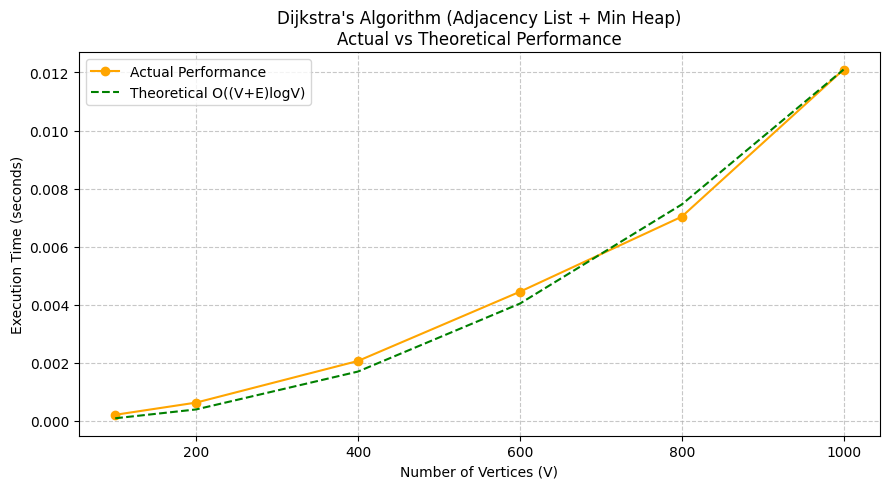

In [7]:
import heapq
import random
import time
import math
import matplotlib.pyplot as plt

# --- Generate random weighted graph using adjacency list ---
def generate_graph(num_vertices, edge_prob=0.1):
    graph = {i: [] for i in range(num_vertices)}
    for i in range(num_vertices):
        for j in range(num_vertices):
            if i != j and random.random() < edge_prob:
                weight = random.randint(1, 10)
                graph[i].append((j, weight))
    return graph

# --- Dijkstra’s algorithm using a min heap ---
def dijkstra(graph, start):
    dist = {v: float('inf') for v in graph}
    dist[start] = 0
    pq = [(0, start)]  # (distance, vertex)

    while pq:
        current_dist, u = heapq.heappop(pq)
        if current_dist > dist[u]:
            continue
        for neighbor, weight in graph[u]:
            new_dist = current_dist + weight
            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist
                heapq.heappush(pq, (new_dist, neighbor))
    return dist

# --- Experiment setup ---
vertex_counts = [100, 200, 400, 600, 800, 1000]
edge_prob = 0.1  # medium density for general performance analysis

actual_times = []
theoretical_times = []

for V in vertex_counts:
    graph = generate_graph(V, edge_prob)
    start = random.choice(list(graph.keys()))
    start_time = time.perf_counter()
    dijkstra(graph, start)
    end_time = time.perf_counter()
    actual = end_time - start_time
    actual_times.append(actual)

    # Theoretical O((V + E) log V)
    E = sum(len(neighbors) for neighbors in graph.values())
    theoretical = (V + E) * math.log(V)
    theoretical_times.append(theoretical)

# --- Normalize theoretical times for visual comparison ---
scale = max(actual_times) / max(theoretical_times)
theoretical_times = [t * scale for t in theoretical_times]

# --- Plot results ---
plt.figure(figsize=(9,5))
plt.plot(vertex_counts, actual_times, 'o-', color='orange', label='Actual Performance')
plt.plot(vertex_counts, theoretical_times, '--', color='green', label='Theoretical O((V+E)logV)')
plt.xlabel('Number of Vertices (V)')
plt.ylabel('Execution Time (seconds)')
plt.title("Dijkstra's Algorithm (Adjacency List + Min Heap)\nActual vs Theoretical Performance")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# (c) Comparisons

We evaluate the runtime efficiency of two **Dijkstra’s Algorithm** implementations:

1. **Adjacency Matrix** using an **Array-based Priority Queue** (from Part a)  
2. **Adjacency List** using a **Min-Heap Priority Queue** (from Part b)

The plots show the average runtime for graphs of different **sizes** and **densities**:

- **Sparse graphs:** contain few edges   
- **Average graphs:** have moderate connectivity   
- **Dense graphs:** are highly connected


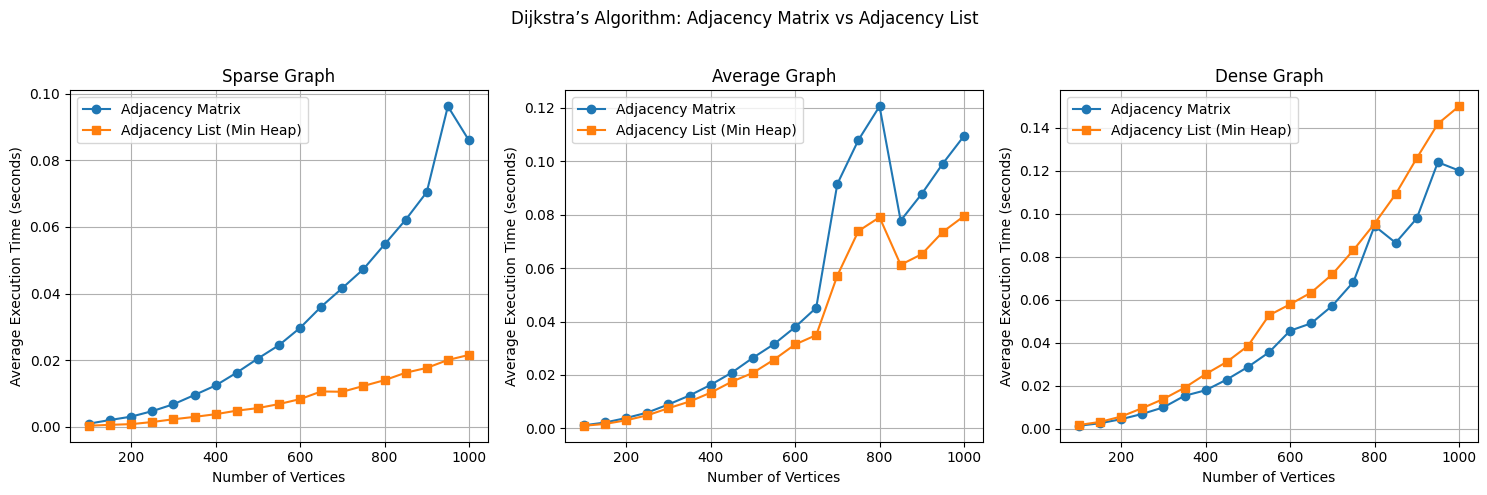

In [10]:
import matplotlib.pyplot as plt
import time
import random

# -------------------------------------------------------------
# Optimized matrix_to_list
# -------------------------------------------------------------
def matrix_to_list(adjMatrix):
    """
    Convert adjacency matrix into adjacency list.
    Avoid O(V^2) scanning — only process non-zero edges once.
    """
    n = len(adjMatrix)
    graph = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):  # only upper triangle
            w = adjMatrix[i][j]
            if w != 0:
                graph[i].append((j, w))
                graph[j].append((i, w))
    return graph


# -------------------------------------------------------------
# Runtime experiment
# -------------------------------------------------------------
def run_experiment(n_values, densities, repeat=1):
    results = {}

    for label, density in densities.items():
        matrix_times, list_times = [], []

        for n in n_values:
            max_edges = n * (n - 1) // 2
            e = int(density * max_edges)

            # --- Generate graph only once per size ---
            matrix_graph = graph_generator(n, e)
            list_graph = matrix_to_list(matrix_graph)

            t_matrix = t_list = 0

            for _ in range(repeat):
                # ---- Matrix + Array Priority Queue ----
                start = time.time()
                dijkstra_matrix_array(matrix_graph, 0)
                t_matrix += time.time() - start

                # ---- List + Min-Heap Priority Queue ----
                start = time.time()
                dijkstra(list_graph, 0)
                t_list += time.time() - start

            matrix_times.append(t_matrix / repeat)
            list_times.append(t_list / repeat)

        results[label] = (matrix_times, list_times)

    return results


# -------------------------------------------------------------
# Execute the experiments
# -------------------------------------------------------------
n_values = list(range(100, 1001, 50))   # No. of vertices
densities = {
    "Sparse Graph": 0.1,
    "Average Graph": 0.5,
    "Dense Graph": 1
}

results = run_experiment(n_values, densities)

# -------------------------------------------------------------
# Plotting
# -------------------------------------------------------------
plt.figure(figsize=(15, 5))
plt.suptitle("Dijkstra’s Algorithm: Adjacency Matrix vs Adjacency List")

for i, (title, (matrix_times, list_times)) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    plt.plot(n_values, matrix_times, 'o-', label="Adjacency Matrix")
    plt.plot(n_values, list_times, 's-', label="Adjacency List (Min Heap)")
    plt.xlabel("Number of Vertices")
    plt.ylabel("Average Execution Time (seconds)")
    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 1. **Sparse Graphs**
- Sparse graphs have very few edges compared to vertices ($E \ll V^2$).  
- The **Adjacency Matrix** checks all possible edges, leading to a fixed cost of $O(V^2)$.  
- The **Adjacency List (Min-Heap)** only processes existing edges with $O((V + E)\log V)$ operations.  
---

### 2. **Average Graphs**
- As graphs become denser, both methods take longer to finish.  
- The **list-based** version performs more heap operations as $E$ increases, while the **matrix-based** version remains $O(V^2)$.  
- Their runtimes **get closer**, but the list version stays slightly faster due to smaller constant factors.

---

### 3. **Dense Graphs**
- Dense graphs have $E \approx V^2$.  
- Both need to explore almost every edge, but the **Adjacency Matrix** is quicker because it uses simple array access and avoids heap overhead.  
- The **Min-Heap** performs many heap operations ($\log V$ each), making it slower.  


### **Conclusion**
| Graph | Dominant operations | Faster implementation |
|-------------|---------------------|------------------------|
| **Sparse** | Heap operations on few edges | Adjacency List (Min-Heap) |
| **Average** | Balanced edge access and heap cost | Adjacency List |
| **Dense** | Full edge traversal; heap overhead dominates | Adjacency Matrix (Array) |

Overall, results align with theoretical complexity:
- $O(V^2)$ for adjacency matrix  
- $O((V + E)\ log V)$ for adjacency list
